Importing data from file

#importing data
import pandas as p

In [ ]:
import re
# read file
text = open('dataset-1.txt', 'r', encoding='utf-8').read()
text = text.replace('\r\n', '\n').replace('\r', '\n')
# text = re.sub(r'(\n\s*\n)+', ' . . . . . ', text) # replace multiple newlines with ' . . . . . '
text = re.sub(r'[-]+', ' ', text) # replace hyphens with space
text = re.sub(r'[^a-zA-Z0-9 \.\n]', '', text) # remove special characters except period
text = re.sub(r'\n\n', ' <EOS> ', text) # replace newlines with space
text = re.sub(r'\.+', '.', text).strip() # collapse multiple spaces into one
text = re.sub(r'\.', ' . ', text) # surround periods with spaces
text = re.sub(r'\s+', ' ', text).strip() # collapse multiple spaces into one
text = text.lower() # convert to lowercase
text = text[:len(text)]  # use only last 90% of the text

In [30]:
import torch
import random
import numpy as np

seed = 42  # or any number you want to fix
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# # for CUDA
# torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)



In [31]:
window_size = 4

paragraphs = text.split(' <eos> ')
# words = [word for para in paragraphs for word in para.split() + ['<EOS>']]
words = []
for para in paragraphs:
    words.extend(para.split(' ') + ['<PAD>'] * window_size)

In [32]:
window_size = 4

X, Y = [], []
for i in range(len(words)):
    start_idx = max(0, i - window_size)
    context = words[start_idx:i]
    context = ['<PAD>'] * (window_size - len(context)) + context  # left padding
    target = words[i]
    
    X.append(context)
    Y.append(target)


for i in range(100):
    print(' '.join(X[i]), '--->', Y[i])


<PAD> <PAD> <PAD> <PAD> ---> well
<PAD> <PAD> <PAD> well ---> prince
<PAD> <PAD> well prince ---> so
<PAD> well prince so ---> genoa
well prince so genoa ---> and
prince so genoa and ---> lucca
so genoa and lucca ---> are
genoa and lucca are ---> now
and lucca are now ---> just
lucca are now just ---> family
are now just family ---> estates
now just family estates ---> of
just family estates of ---> the
family estates of the ---> buonapartes
estates of the buonapartes ---> .
of the buonapartes . ---> but
the buonapartes . but ---> i
buonapartes . but i ---> warn
. but i warn ---> you
but i warn you ---> if
i warn you if ---> you
warn you if you ---> dont
you if you dont ---> tell
if you dont tell ---> me
you dont tell me ---> that
dont tell me that ---> this
tell me that this ---> means
me that this means ---> war
that this means war ---> if
this means war if ---> you
means war if you ---> still
war if you still ---> try
if you still try ---> to
you still try to ---> defend
still try t

In [33]:
from collections import Counter

word_counts = Counter(words)
vocab = sorted(word_counts.keys()) 
vocab_size = len(vocab)

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 1477


In [34]:
most_common_10 = word_counts.most_common(10)
least_common_10 = word_counts.most_common()[-10:]

print("10 Most Frequent Words:", most_common_10)
print("10 Least Frequent Words:", least_common_10)


10 Most Frequent Words: [('<PAD>', 448), ('the', 283), ('.', 256), ('and', 213), ('to', 185), ('of', 133), ('a', 122), ('her', 99), ('he', 81), ('in', 80)]
10 Least Frequent Words: [('ingratiating', 1), ('appealing', 1), ('cost', 1), ('transferred', 1), ('guards', 1), ('difficult', 1), ('advise', 1), ('appeal', 1), ('rumyantsev', 1), ('golit', 1)]


In [35]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using Apple Silicon GPU (MPS)


In [36]:
stoi = {word: i for i, word in enumerate(vocab)}
itos = {i: word for word, i in stoi.items()}
emb_dim = 64
emb = torch.nn.Embedding(len(stoi), emb_dim)
print(stoi)
print(itos)

{'.': 0, '10': 1, '1805': 2, '7': 3, '<PAD>': 4, 'a': 5, 'abbe': 6, 'abbes': 7, 'ability': 8, 'abnegation': 9, 'about': 10, 'abroad': 11, 'accorded': 12, 'accounts': 13, 'acquaintance': 14, 'act': 15, 'actions': 16, 'active': 17, 'actor': 18, 'actress': 19, 'added': 20, 'addressing': 21, 'adjusting': 22, 'admiring': 23, 'admitting': 24, 'adopted': 25, 'adored': 26, 'advantageous': 27, 'advise': 28, 'affair': 29, 'affectation': 30, 'affected': 31, 'affectionate': 32, 'afraid': 33, 'after': 34, 'again': 35, 'age': 36, 'agitated': 37, 'ah': 38, 'aide': 39, 'alarm': 40, 'alarmed': 41, 'alexanders': 42, 'alike': 43, 'all': 44, 'alliance': 45, 'allowing': 46, 'almost': 47, 'alone': 48, 'also': 49, 'altered': 50, 'altering': 51, 'although': 52, 'always': 53, 'am': 54, 'amazingly': 55, 'ambassadors': 56, 'amiable': 57, 'amiably': 58, 'amid': 59, 'among': 60, 'an': 61, 'anatole': 62, 'and': 63, 'andre': 64, 'andrew': 65, 'anecdote': 66, 'animated': 67, 'animation': 68, 'anna': 69, 'annette': 70

In [37]:
print(emb.weight.shape)  # should be (vocab_size, emb_dim)

torch.Size([1477, 64])


In [38]:
X_encoded = [[stoi[word] for word in seq] for seq in X]
Y_encoded = [stoi[word] for word in Y] 

In [41]:
X = torch.tensor(X_encoded, dtype=torch.long).to(device)
Y = torch.tensor(Y_encoded, dtype=torch.long).to(device)

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [45]:
class Nextword(nn.Module):
    def __init__(self, block_size, vocab_size, emb_dim=64, hidden_size=1024):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.fc1 = nn.Linear(block_size * emb_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x: (batch, block_size)
        x = self.emb(x)                           # (batch, block_size, emb_dim)
        x = x.view(x.shape[0], -1)                # flatten
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        x = self.fc3(x)                           # logits
        return x



In [46]:
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
train_data = torch.utils.data.TensorDataset(X_train, Y_train)
val_data = torch.utils.data.TensorDataset(X_val, Y_val)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32)



In [47]:
import time
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_model_summary(model):
    print("Model Summary:")
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:
            params = sum(p.numel() for p in module.parameters())
            print(f"{name:<20} {params:,} parameters")
    print(f"\nTotal trainable parameters: {count_params(model):,}\n")


import torch
import torch.nn as nn
import time

def train_model(model, X, Y, X_val, Y_val, epochs=500, batch_size=1024, lr=1e-3, wd=1e-4, print_every=100):
    """Train the MLP model using AdamW optimizer."""
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    losses, times, val_losses = [], [], []

    for epoch in range(epochs):
        start = time.time()
        total_loss, n_batches = 0, 0

        # -------- Training --------
        for i in range(0, X.shape[0], batch_size):
            x_batch = X[i:i+batch_size]
            y_batch = Y[i:i+batch_size]

            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches
        losses.append(avg_loss)
        times.append(time.time() - start)

        # -------- Validation --------
        model.eval()
        val_total_loss, val_batches = 0, 0
        with torch.no_grad():
            for i in range(0, X_val.shape[0], batch_size):
                x_batch = X_val[i:i+batch_size]
                y_batch = Y_val[i:i+batch_size]

                logits = model(x_batch)
                loss = loss_fn(logits, y_batch)
                val_total_loss += loss.item()
                val_batches += 1

        avg_val_loss = val_total_loss / val_batches
        val_losses.append(avg_val_loss)
        model.train()

        # -------- Logging --------
        if epoch % print_every == 0:
            print(f"Epoch {epoch:4d} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {times[-1]:.2f}s")

    return losses, times, val_losses


In [48]:
# Create enhanced model and show before training
block_size = 4
model = Nextword(block_size, len(stoi), emb_dim).to(device)
model = torch.compile(model)

## Model parameters:
print_model_summary(model)


Model Summary:
_orig_mod.emb        94,528 parameters
_orig_mod.fc1        263,168 parameters
_orig_mod.fc2        1,049,600 parameters
_orig_mod.fc3        1,513,925 parameters

Total trainable parameters: 2,921,221



In [49]:
import torch

def generate_text(model, stoi, itos, block_size, device, start_context=None, max_len=20):
    """
    Generate a sequence of words from a trained model.

    Args:
        model: Trained PyTorch language model
        stoi: dict, mapping from word → index
        itos: dict, mapping from index → word
        block_size: int, context size expected by the model
        device: torch device ('cuda' or 'cpu')
        start_context: list of str (optional), seed words
        max_len: int, number of words to generate

    Returns:
        str: Generated text sequence
    """

    model.eval()  # evaluation mode (no dropout, etc.)

    # --- Initialize context ---
    if start_context is None:
        context = [stoi['<PAD>']] * block_size  # start with padding
    else:
        # convert words → indices, pad or truncate to block_size
        context = [stoi.get(w, 0) for w in start_context][-block_size:]
        context = [stoi['<PAD>']] * (block_size - len(context)) + context

    generated_words = []

    # --- Generate words one by one ---
    with torch.no_grad():
        for _ in range(max_len):
            x = torch.tensor(context).view(1, -1).to(device)
            y_pred = model(x)  # logits for next word
            ix = torch.distributions.categorical.Categorical(logits=y_pred).sample().item()
            word = itos[ix]

            # stop at end token 
            # if word == eos:
            #     break

            generated_words.append(word)

            # slide the context window forward
            context = context[1:] + [ix]

    model.train()  # restore training mode

    return ' '.join(generated_words)


In [50]:
text = generate_text(model, stoi, itos, block_size=4, device=device)
print(text)

abbes ambassadors glamour boats midst repaid genoa ugly eat asking speaker duc sure criticize goes thing elderly educated by unpleasant


In [51]:
losses, timing , val_losses = train_model(model, X_train, Y_train,X_val,Y_val, epochs=500, batch_size=1024, lr=1e-3, wd=1e-4, print_every=100)

Epoch    0 | Train Loss: 6.9185 | Val Loss: 6.5482 | Time: 1.11s
Epoch  100 | Train Loss: 0.0934 | Val Loss: 8.9735 | Time: 0.08s
Epoch  200 | Train Loss: 0.0904 | Val Loss: 9.4203 | Time: 0.08s
Epoch  300 | Train Loss: 0.0895 | Val Loss: 9.6837 | Time: 0.07s
Epoch  400 | Train Loss: 0.0891 | Val Loss: 9.8733 | Time: 0.08s


In [52]:
text = generate_text(model, stoi, itos, block_size=4, device=device, start_context="maid of honor and favorite", max_len=50)
print(text)

<PAD> <PAD> <PAD> <PAD> i cant help knew frightened the the circle of which . <PAD> <PAD> <PAD> <PAD> you think so rejoined anna pavlovna in order to say that and the lofty destiny of the adored monarch . he will save europe . and gracious sovereign recognizes his high


In [53]:
import pandas as pd
df = pd.DataFrame({
    'Epoch': range(1, len(losses) + 1),
    'Train_Loss': losses,
    'Val_Loss': val_losses,
    'Timing': timing
})
df.to_csv('training_log.csv', index=False)



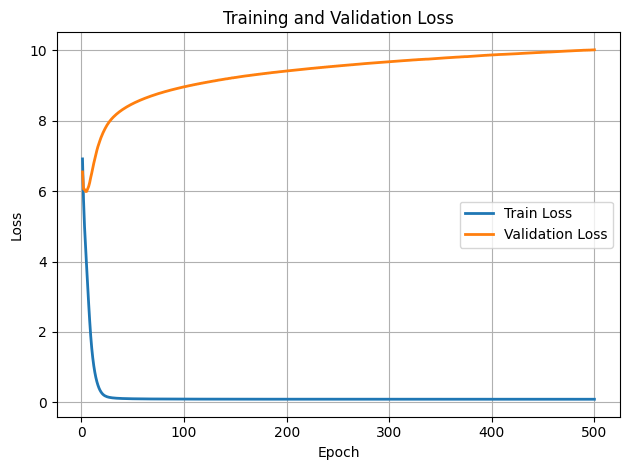

In [54]:
import matplotlib.pyplot as plt

plt.plot(df['Epoch'], df['Train_Loss'], label='Train Loss', linewidth=2)
plt.plot(df['Epoch'], df['Val_Loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
from google.colab import drive
drive.mount('/content/drive')

# 1. Define a permanent path in your Google Drive
# This will save it to a folder called "MyModels" in your main Drive
save_path = '/content/drive/MyDrive/MyModels/model_4_64_relu_42.pth'

# 2. Save the model
torch.save(model.state_dict(), save_path)

ModuleNotFoundError: No module named 'google.colab'

In [56]:
torch.save(model.state_dict(), 'model_4_64_relu_42.pth')